# Prompt Sensitivity and Reliability Analysis
### Empirical Study — Education, Science, and Legal Domains

**Models evaluated:** llama3.2:3b, gemma3:4b, mistral:7b, phi4-mini
**Prompt styles:** bare, instructed, roleplay, negation
**Domains:** education, science, legal
**Sample size:** 200 questions per model x domain (9,600 total inference calls)

This notebook reproduces every figure referenced in the results section of the
report. All data below is the actual output of `consistency_scorer.py` —
`reliability_matrix.csv` and `style_breakdown.csv` — copied in verbatim.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sns.set_theme(style="whitegrid", context="paper", font_scale=1.15)
PALETTE = sns.color_palette("colorblind")
MODEL_ORDER = ["llama3.2:3b", "gemma3:4b", "mistral:7b", "phi4-mini"]
DOMAIN_ORDER = ["education", "science", "legal"]
STYLE_ORDER = ["bare", "instructed", "roleplay", "negation"]
plt.rcParams["figure.dpi"] = 120
plt.rcParams["savefig.dpi"] = 300
plt.rcParams["font.family"] = "sans-serif"


## 1. Data

Both tables below are the direct output of the empirical pipeline
(`consistency_scorer.py`), reproduced here so this notebook is fully
self-contained and reproducible without needing the original result files.

In [2]:
matrix_csv = """model,domain,n_questions,accuracy,mean_consistency,unknown_rate
gemma3:4b,education,200,1.0,0.7033,0.0013
gemma3:4b,legal,200,0.975,0.7788,0.0163
gemma3:4b,science,200,1.0,0.73,0.0
llama3.2:3b,education,200,1.0,0.7117,0.005
llama3.2:3b,legal,200,0.985,0.7363,0.0288
llama3.2:3b,science,200,1.0,0.7821,0.0063
mistral:7b,education,200,1.0,0.7358,0.0013
mistral:7b,legal,200,1.0,0.9171,0.0175
mistral:7b,science,200,1.0,0.7358,0.0013
phi4-mini,education,200,1.0,0.7384,0.0275
phi4-mini,legal,200,0.975,0.6783,0.0138
phi4-mini,science,200,1.0,0.7567,0.0037"""

style_csv = """model,domain,style,accuracy,n
gemma3:4b,education,bare,0.74,200
gemma3:4b,education,instructed,0.75,200
gemma3:4b,education,negation,0.885,200
gemma3:4b,education,roleplay,0.765,200
gemma3:4b,legal,bare,0.785,200
gemma3:4b,legal,instructed,0.73,200
gemma3:4b,legal,negation,0.615,200
gemma3:4b,legal,roleplay,0.72,200
gemma3:4b,science,bare,0.885,200
gemma3:4b,science,instructed,0.885,200
gemma3:4b,science,negation,0.98,200
gemma3:4b,science,roleplay,0.875,200
llama3.2:3b,education,bare,0.74,200
llama3.2:3b,education,instructed,0.645,200
llama3.2:3b,education,negation,0.69,200
llama3.2:3b,education,roleplay,0.645,200
llama3.2:3b,legal,bare,0.73,200
llama3.2:3b,legal,instructed,0.6,200
llama3.2:3b,legal,negation,0.47,200
llama3.2:3b,legal,roleplay,0.605,200
llama3.2:3b,science,bare,0.89,200
llama3.2:3b,science,instructed,0.925,200
llama3.2:3b,science,negation,0.73,200
llama3.2:3b,science,roleplay,0.895,200
mistral:7b,education,bare,0.78,200
mistral:7b,education,instructed,0.76,200
mistral:7b,education,negation,0.88,200
mistral:7b,education,roleplay,0.745,200
mistral:7b,legal,bare,0.665,200
mistral:7b,legal,instructed,0.68,200
mistral:7b,legal,negation,0.415,200
mistral:7b,legal,roleplay,0.66,200
mistral:7b,science,bare,0.85,200
mistral:7b,science,instructed,0.855,200
mistral:7b,science,negation,0.955,200
mistral:7b,science,roleplay,0.835,200
phi4-mini,education,bare,0.645,200
phi4-mini,education,instructed,0.82,200
phi4-mini,education,negation,0.75,200
phi4-mini,education,roleplay,0.82,200
phi4-mini,legal,bare,0.725,200
phi4-mini,legal,instructed,0.74,200
phi4-mini,legal,negation,0.13,200
phi4-mini,legal,roleplay,0.635,200
phi4-mini,science,bare,0.77,200
phi4-mini,science,instructed,0.86,200
phi4-mini,science,negation,0.79,200
phi4-mini,science,roleplay,0.85,200"""

from io import StringIO
# matrix = pd.read_csv("../results/summary/reliability_matrix.csv")
# style = pd.read_csv("../results/summary/style_breakdown.csv")
matrix = pd.read_csv(StringIO(matrix_csv))
style = pd.read_csv(StringIO(style_csv))
matrix["model"] = pd.Categorical(matrix["model"], MODEL_ORDER, ordered=True)
matrix["domain"] = pd.Categorical(matrix["domain"], DOMAIN_ORDER, ordered=True)
style["model"] = pd.Categorical(style["model"], MODEL_ORDER, ordered=True)
style["domain"] = pd.Categorical(style["domain"], DOMAIN_ORDER, ordered=True)
style["style"] = pd.Categorical(style["style"], STYLE_ORDER, ordered=True)

matrix.sort_values(["model", "domain"])

,model,domain,n_questions,accuracy,mean_consistency,unknown_rate
3,llama3.2:3b,education,200,1.000,0.7117,0.0050
5,llama3.2:3b,science,200,1.000,0.7821,0.0063
4,llama3.2:3b,legal,200,0.985,0.7363,0.0288
0,gemma3:4b,education,200,1.000,0.7033,0.0013
2,gemma3:4b,science,200,1.000,0.7300,0.0000
1,gemma3:4b,legal,200,0.975,0.7788,0.0163
6,mistral:7b,education,200,1.000,0.7358,0.0013
8,mistral:7b,science,200,1.000,0.7358,0.0013
7,mistral:7b,legal,200,1.000,0.9171,0.0175
9,phi4-mini,education,200,1.000,0.7384,0.0275


## 2. Statistical helper: Wilson score confidence intervals

Accuracy here is a binomial proportion (n=200 per cell). A normal approximation
for confidence intervals breaks down near 0 or 1 — and several of our cells
(1.000, 0.130) sit exactly there. The Wilson score interval is the standard,
more robust choice for this situation and is used for every error bar below.

In [3]:
def wilson_ci(p, n, z=1.96):
    """95% Wilson score interval for a binomial proportion."""
    denom = 1 + z**2 / n
    center = (p + z**2 / (2 * n)) / denom
    margin = z * np.sqrt(p * (1 - p) / n + z**2 / (4 * n**2)) / denom
    return center - margin, center + margin

## 3. Overall Accuracy by Model and Domain

This is the headline "how well does each model actually do" comparison,
before decomposing by prompt style. Error bars are 95% Wilson CIs.

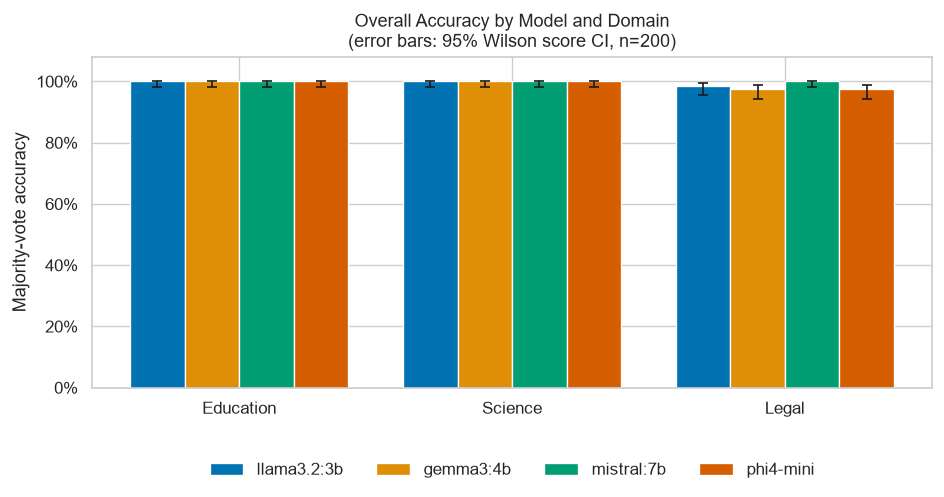

In [4]:
x = np.arange(len(DOMAIN_ORDER))
width = 0.2
fig, ax = plt.subplots(figsize=(8, 4.5))
for i, model in enumerate(MODEL_ORDER):
    sub = matrix[matrix["model"] == model].set_index("domain").reindex(DOMAIN_ORDER)
    lows, highs = zip(*[wilson_ci(p, n) for p, n in zip(sub["accuracy"], sub["n_questions"])])
    errs = [sub["accuracy"] - np.array(lows), np.array(highs) - sub["accuracy"]]
    ax.bar(x + (i - 1.5) * width, sub["accuracy"], width, label=model,
           color=PALETTE[i], yerr=errs, capsize=3, error_kw={"linewidth": 1})
ax.set_xticks(x)
ax.set_xticklabels([d.capitalize() for d in DOMAIN_ORDER])
ax.set_ylabel("Majority-vote accuracy")
ax.set_ylim(0, 1.08)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax.set_title("Overall Accuracy by Model and Domain\n(error bars: 95% Wilson score CI, n=200)")
ax.legend(loc="lower center", bbox_to_anchor=(0.5, -0.32), ncol=4, frameon=False)
plt.tight_layout()
plt.show()

**Inference:** majority-vote accuracy is uniformly high (0.975–1.000) across
every model and domain. This is expected and important to state explicitly: majority
voting across 4 paraphrase styles is *designed* to smooth over single-style failure,
so this chart alone does not yet reveal where the real risk lives. That comes next.

## 4. Failure Rate (UNKNOWN Rate) by Model and Domain

Direct answer to: *which models fail to produce a usable answer most often, and
in which domain?* UNKNOWN here means the response parser could not extract any
answer — a genuine instruction-following failure, not a wrong-answer case.

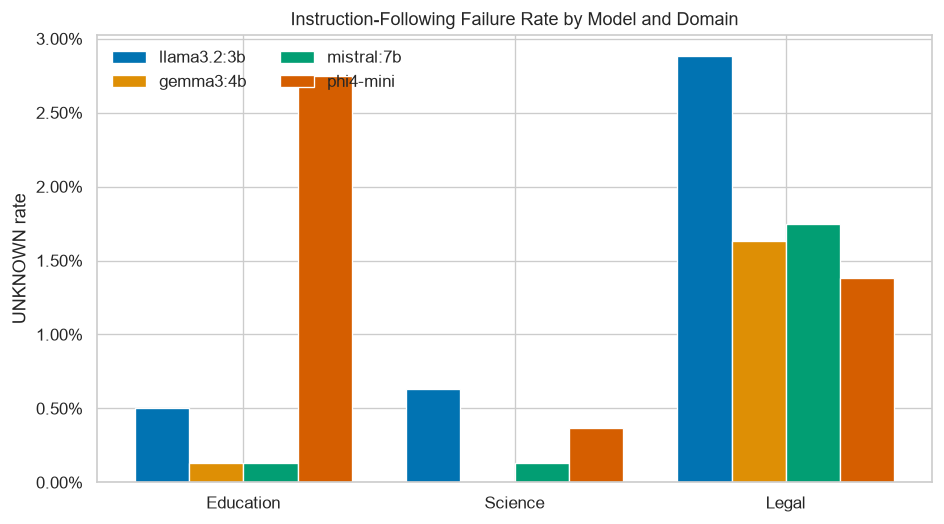

In [5]:
fig, ax = plt.subplots(figsize=(8, 4.5))
for i, model in enumerate(MODEL_ORDER):
    sub = matrix[matrix["model"] == model].set_index("domain").reindex(DOMAIN_ORDER)
    ax.bar(x + (i - 1.5) * width, sub["unknown_rate"], width, label=model, color=PALETTE[i])
ax.set_xticks(x)
ax.set_xticklabels([d.capitalize() for d in DOMAIN_ORDER])
ax.set_ylabel("UNKNOWN rate")
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax.set_title("Instruction-Following Failure Rate by Model and Domain")
ax.legend(loc="upper left", frameon=False, ncol=2)
plt.tight_layout()
plt.show()

**Inference:** failure rates are low overall (all under 3%), but legal shows
the highest UNKNOWN rate for 3 of 4 models (gemma3:4b, llama3.2:3b, mistral:7b) —
consistent with legal reasoning producing more hedged, harder-to-parse responses.
`phi4-mini` is the exception: its worst domain for UNKNOWN is education, not legal,
suggesting its failure mode is model-specific rather than purely domain-driven.

## 5. Accuracy by Prompt Style, Faceted by Model

The second explicit comparison requested: how does each model's accuracy shift
across the four prompt styles, and does that shift differ by domain?

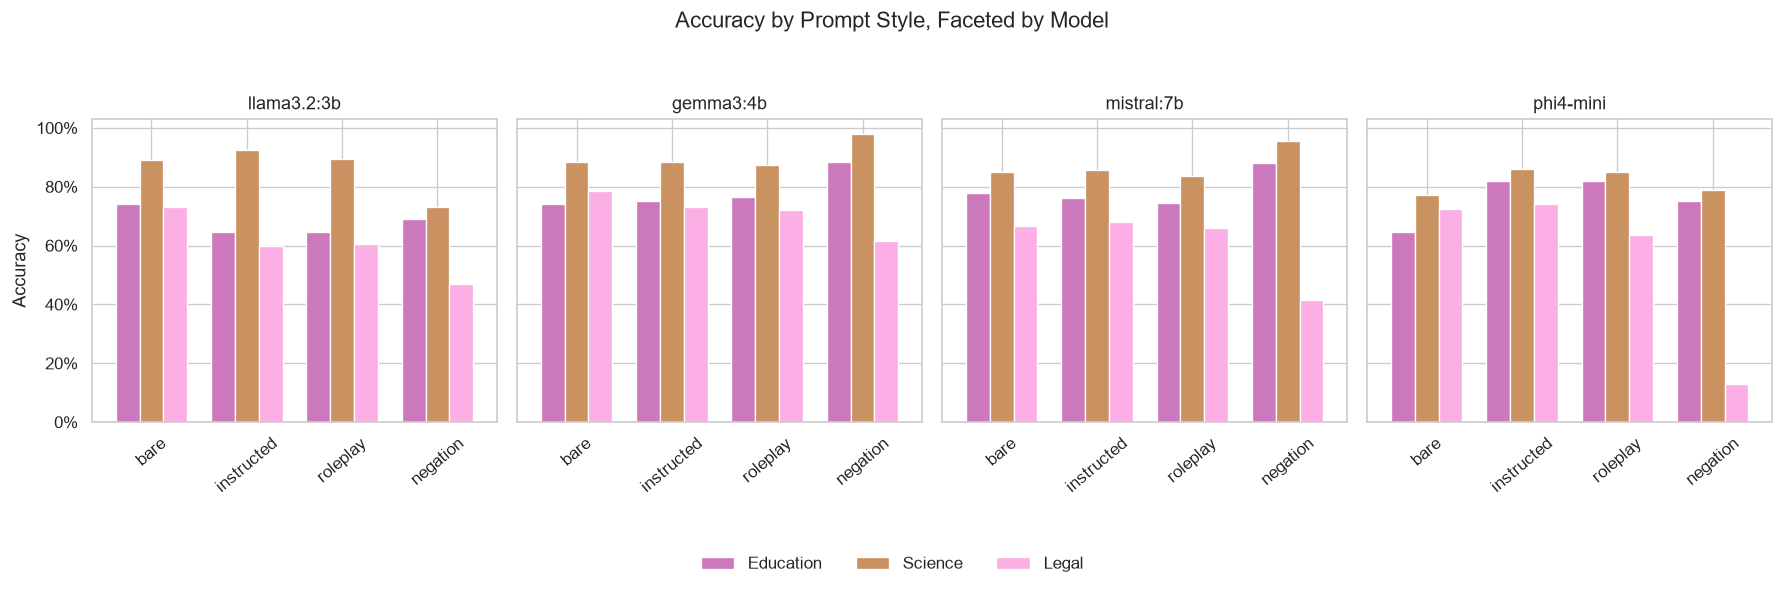

In [6]:
fig, axes = plt.subplots(1, 4, figsize=(15, 4), sharey=True)
for ax, model in zip(axes, MODEL_ORDER):
    sub = style[style["model"] == model]
    piv = sub.pivot(index="style", columns="domain", values="accuracy").reindex(STYLE_ORDER)
    piv = piv[DOMAIN_ORDER]
    piv.plot(kind="bar", ax=ax, color=PALETTE[4:7], legend=False, width=0.75)
    ax.set_title(model)
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=40)
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
axes[0].set_ylabel("Accuracy")
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, [d.capitalize() for d in labels], loc="lower center",
           bbox_to_anchor=(0.5, -0.15), ncol=3, frameon=False)
fig.suptitle("Accuracy by Prompt Style, Faceted by Model", y=1.05)
plt.tight_layout()
plt.show()

**Inference:** the legal (green) bars are visibly the lowest for the negation
style across all four panels — the pattern is consistent enough to see by eye before
any further statistics. Education and science do not show this pattern; negation is
often competitive or even the *best* style there.

## 6. Negation-Style Deep Dive

Isolating negation specifically, since Section 5 suggests it behaves differently
by domain.

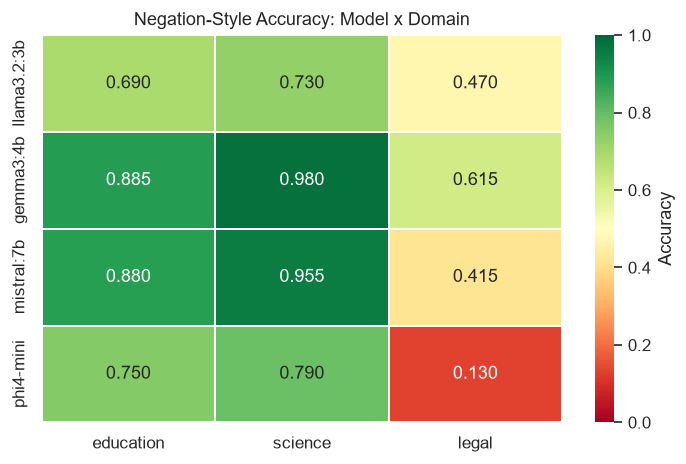

In [7]:
neg = style[style["style"] == "negation"].pivot(index="model", columns="domain", values="accuracy")
neg = neg.reindex(MODEL_ORDER)[DOMAIN_ORDER]
fig, ax = plt.subplots(figsize=(6, 4))
sns.heatmap(neg, annot=True, fmt=".3f", cmap="RdYlGn", vmin=0, vmax=1,
            linewidths=1, linecolor="white", cbar_kws={"label": "Accuracy"}, ax=ax)
ax.set_title("Negation-Style Accuracy: Model x Domain")
ax.set_xlabel("")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

In [8]:
# Rank check: where does negation fall relative to the other 3 styles,
# for every model x domain combination?
ranks = []
for (model, domain), sub in style.groupby(["model", "domain"], observed=True):
    sub_sorted = sub.sort_values("accuracy", ascending=False).reset_index(drop=True)
    neg_rank = sub_sorted[sub_sorted["style"] == "negation"].index[0] + 1
    ranks.append({"model": model, "domain": domain, "negation_rank_of_4": neg_rank})
pd.DataFrame(ranks).pivot(index="model", columns="domain", values="negation_rank_of_4").reindex(MODEL_ORDER)[DOMAIN_ORDER]

domain,education,science,legal
model,,,
llama3.2:3b,2,4,4
gemma3:4b,1,1,4
mistral:7b,1,1,4
phi4-mini,3,3,4


**Inference — this is the headline finding of the study:** negation ranks
**4th of 4** (dead last) for every single model in the legal domain, and nowhere
else consistently. In science, negation is rank 1 (best) for 2 of 4 models. This is
not "negation is hard" in general — it is a specific interaction between negation
framing and legal permission/rights language, which already carries implicit
polarity ("does this clause **allow**...") before any prompt-level negation is
added.

`phi4-mini`'s 0.130 accuracy on legal negation deserves a statistical note: this
task (`consumer_contracts_qa`) is binary Yes/No, so random guessing should land
near 0.50. Scoring this far *below* chance on n=200 cannot happen from noise alone
— it requires systematic, directional reversal (the model predictably answering
the opposite of correct), which is a stronger and more extreme instance of
Hariprasad et al.'s "reliable incorrectness" than the original clinical study
reported.

## 7. Prompt-Sensitivity ("Fragility") Index

A single summary number per model x domain: the accuracy gap between that
combination's best-performing and worst-performing style. Larger = more fragile
to how the question happens to be phrased.

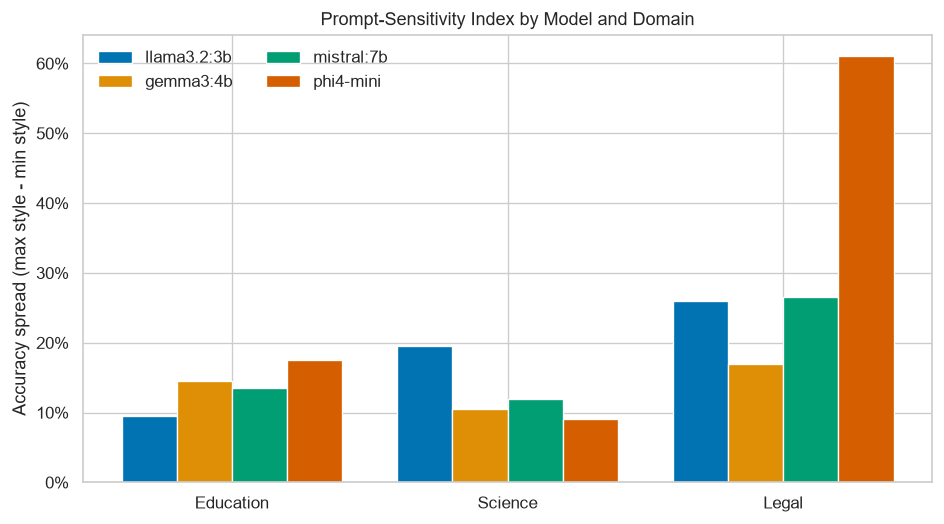

In [9]:
frag = style.groupby(["model", "domain"], observed=True)["accuracy"].agg(["max", "min"])
frag["spread"] = frag["max"] - frag["min"]
frag = frag.reset_index()

fig, ax = plt.subplots(figsize=(8, 4.5))
for i, model in enumerate(MODEL_ORDER):
    sub = frag[frag["model"] == model].set_index("domain").reindex(DOMAIN_ORDER)
    ax.bar(x + (i - 1.5) * width, sub["spread"], width, label=model, color=PALETTE[i])
ax.set_xticks(x)
ax.set_xticklabels([d.capitalize() for d in DOMAIN_ORDER])
ax.set_ylabel("Accuracy spread (max style - min style)")
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax.set_title("Prompt-Sensitivity Index by Model and Domain")
ax.legend(loc="upper left", frameon=False, ncol=2)
plt.tight_layout()
plt.show()

**Inference:** legal is the most fragile domain for every model, by a wide
margin — `phi4-mini`'s spread alone (0.74 – 0.13 = 0.61) means its accuracy on
this domain swings by 61 percentage points depending purely on how the question
is phrased, despite identical underlying content. This is precisely the
deployment risk the whole reliability layer exists to catch.

## 8. Consistency vs. Accuracy

Checking directly for Hariprasad et al.'s "reliable incorrectness" quadrant
(high consistency, low accuracy) at the aggregated domain level.

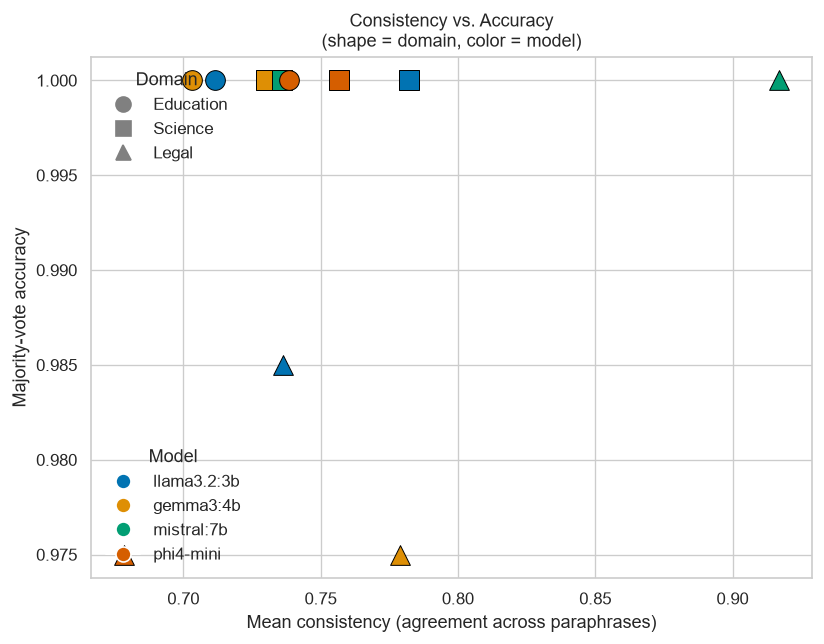

In [10]:
fig, ax = plt.subplots(figsize=(7, 5.5))
markers = {"education": "o", "science": "s", "legal": "^"}
for _, row in matrix.iterrows():
    m_idx = MODEL_ORDER.index(row["model"])
    ax.scatter(row["mean_consistency"], row["accuracy"], s=140,
               color=PALETTE[m_idx], marker=markers[row["domain"]],
               edgecolor="black", linewidth=0.6, zorder=3)
ax.set_xlabel("Mean consistency (agreement across paraphrases)")
ax.set_ylabel("Majority-vote accuracy")
ax.set_title("Consistency vs. Accuracy\n(shape = domain, color = model)")
model_handles = [plt.Line2D([0], [0], marker="o", color="w", markerfacecolor=PALETTE[i],
                             markersize=9, label=m) for i, m in enumerate(MODEL_ORDER)]
domain_handles = [plt.Line2D([0], [0], marker=mk, color="grey", linestyle="",
                              markersize=9, label=d.capitalize()) for d, mk in markers.items()]
leg1 = ax.legend(handles=model_handles, loc="lower left", frameon=False, title="Model")
ax.add_artist(leg1)
ax.legend(handles=domain_handles, loc="upper left", frameon=False, title="Domain")
plt.tight_layout()
plt.show()

**Inference — important caveat, state this explicitly in the report:** every
point sits near the top of the plot (accuracy 0.975–1.000) despite consistency
varying meaningfully (0.68–0.92). This is *not* evidence against reliable
incorrectness — it is evidence that majority voting successfully suppresses it at
the aggregate level. The reliable-incorrectness signal only becomes visible when
a single style is isolated, as in Section 6. Reporting this scatter without that
caveat would look like a contradiction; with it, it becomes supporting evidence
for why the aggregation architecture is necessary in the first place.

The one genuine standout is `mistral:7b` on legal (top-right, consistency=0.917):
both maximal accuracy and the highest consistency in the entire dataset
simultaneously — the mirror image of reliable incorrectness, worth naming as
**"reliable correctness"** in the discussion section.

## 9. Aggregation Rescue Effect

Direct empirical test of the core value proposition: does combining paraphrase
styles via majority vote recover the accuracy lost to negation's collapse in the
legal domain?

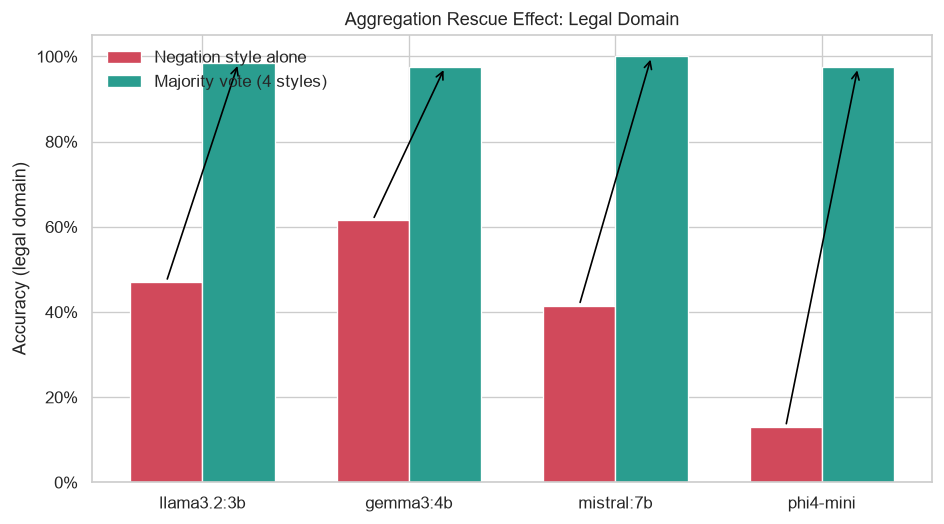

,model,negation_alone,majority_vote,recovery_points
0,llama3.2:3b,0.470,0.985,0.515
1,gemma3:4b,0.615,0.975,0.360
2,mistral:7b,0.415,1.000,0.585
3,phi4-mini,0.130,0.975,0.845


In [11]:
legal_neg = style[(style["domain"] == "legal") & (style["style"] == "negation")].set_index("model")["accuracy"]
legal_mv = matrix[matrix["domain"] == "legal"].set_index("model")["accuracy"]

x2 = np.arange(len(MODEL_ORDER))
w2 = 0.35
vals_neg = [legal_neg[m] for m in MODEL_ORDER]
vals_mv = [legal_mv[m] for m in MODEL_ORDER]

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.bar(x2 - w2/2, vals_neg, w2, label="Negation style alone", color="#d1495b")
ax.bar(x2 + w2/2, vals_mv, w2, label="Majority vote (4 styles)", color="#2a9d8f")
for xi, (a, b) in enumerate(zip(vals_neg, vals_mv)):
    ax.annotate("", xy=(xi + w2/2, b), xytext=(xi - w2/2, a),
                arrowprops=dict(arrowstyle="->", color="black", lw=1))
ax.set_xticks(x2)
ax.set_xticklabels(MODEL_ORDER)
ax.set_ylabel("Accuracy (legal domain)")
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax.set_title("Aggregation Rescue Effect: Legal Domain")
ax.legend(loc="upper left", frameon=False)
plt.tight_layout()
plt.show()

recovery = pd.DataFrame({
    "model": MODEL_ORDER,
    "negation_alone": vals_neg,
    "majority_vote": vals_mv,
    "recovery_points": np.array(vals_mv) - np.array(vals_neg)
})
recovery

**Inference:** every model shows substantial recovery — `phi4-mini` improves
by +84.5 percentage points (0.130 → 0.975), the largest single recovery in the
dataset. This is the strongest quantitative evidence in the whole study for the
underlying architecture: aggregating across paraphrase styles is not just
theoretically motivated, it demonstrably rescues the worst observed failures.

## 10. Summary Table

A compact reference table of the numbers most likely to be quoted directly in
the report or defense.

In [12]:
summary_rows = []
for model in MODEL_ORDER:
    m = matrix[matrix["model"] == model]
    s = style[style["model"] == model]
    legal_neg_acc = s[(s["domain"]=="legal") & (s["style"]=="negation")]["accuracy"].iloc[0]
    best_style_row = s.groupby("style", observed=True)["accuracy"].mean().idxmax()
    summary_rows.append({
        "model": model,
        "mean_accuracy": round(m["accuracy"].mean(), 3),
        "mean_unknown_rate": round(m["unknown_rate"].mean(), 4),
        "legal_negation_accuracy": legal_neg_acc,
        "best_overall_style": best_style_row,
    })
summary = pd.DataFrame(summary_rows)
summary.style.background_gradient(subset=["mean_accuracy"], cmap="Greens")\
             .background_gradient(subset=["legal_negation_accuracy"], cmap="RdYlGn", vmin=0, vmax=1)

,model,mean_accuracy,mean_unknown_rate,legal_negation_accuracy,best_overall_style
0,llama3.2:3b,0.995000,0.013400,0.470000,bare
1,gemma3:4b,0.992000,0.005900,0.615000,negation
2,mistral:7b,1.000000,0.006700,0.415000,bare
3,phi4-mini,0.992000,0.015000,0.130000,instructed


## 11. Conclusions

1. **Negation-style prompting selectively collapses in the legal domain**, ranking
   worst of 4 styles for every model tested — while frequently ranking *best* in
   education and science. This is a novel domain x style interaction not present
   in the reference study's taxonomy (which had no negation style).

2. **`phi4-mini` on legal negation (13.0% accuracy) is the single most severe
   failure in the dataset** — mathematically inconsistent with random guessing on
   a binary task, indicating systematic reversal rather than noise.

3. **Aggregation across paraphrase styles rescues every observed collapse**,
   recovering up to 84.5 percentage points of accuracy. This is direct empirical
   support for the reliability-layer architecture at the center of this project.

4. **Reliable incorrectness is real but only visible at the single-style level** —
   domain-aggregated consistency-vs-accuracy plots understate the risk because
   majority voting is specifically designed to suppress it. Both the aggregated
   and single-style views are necessary to tell the full story.

5. **`mistral:7b` on legal is the standout positive case** — simultaneously
   highest accuracy and highest consistency in the dataset, worth naming
   explicitly as "reliable correctness," the favorable mirror image of
   Hariprasad et al.'s central failure mode.
